In [473]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
#for statistical tests
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
from scipy.stats import shapiro, pearsonr, spearmanr

In [474]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "additional_material/clean_inflation_df.csv"
github_url = f"https://raw.githubusercontent.com/{username}/{repository}/main/{directory}"
wb_df = pd.read_csv(github_url)

In [475]:
#print the WB data frame shape
print("World Bank DataFrame Shape:", wb_df.shape)

World Bank DataFrame Shape: (12924, 25)


In [476]:
#print column names
print("World Bank DataFrame Columns:", wb_df.columns.tolist())

World Bank DataFrame Columns: ['country', 'code', 'region', 'income_group', 'lending_category', 'year', 'agricultural_land_pct', 'forest_land_pct', 'control_of_corruption_estimate', 'access_to_electricity_pct', 'renewable_energy_consumption_pct', 'co2_emissions', 'pop_density', 'inflation_yr_pct', 'tax_revenue_pct', 'gov_effectiveness_estimate', 'gdp_current_usd_M', 'political_stability_estimate', 'rule_of_law_estimate', 'gov_exp_on_education_pct', 'gov_health_exp_pct', 'life_expectancy_at_birth', 'pop_M', 'voice_and_accountability_estimate', 'co2_per_capita_t']


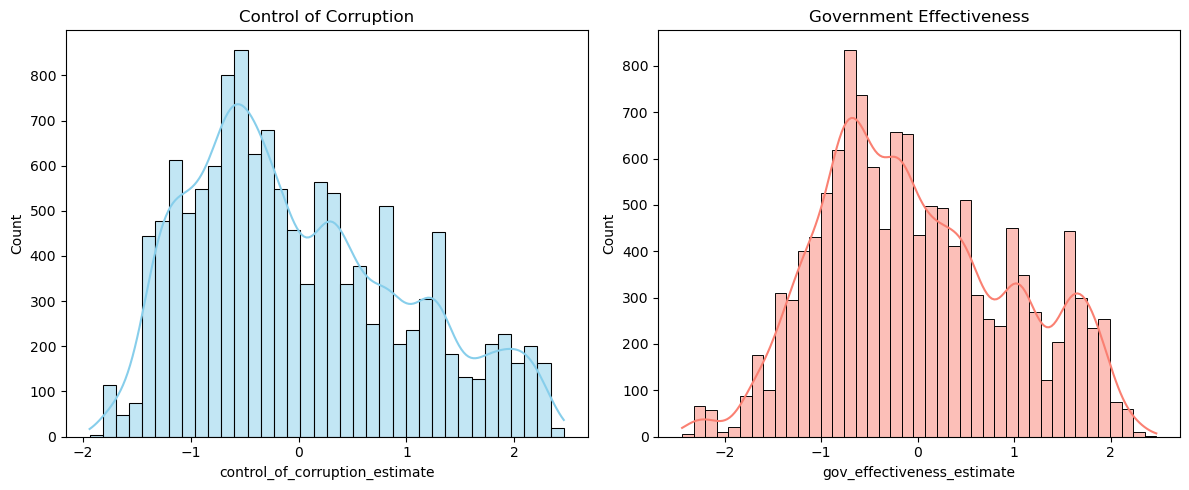

In [477]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

sns.histplot(wb_df['control_of_corruption_estimate'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Control of Corruption')

sns.histplot(wb_df['gov_effectiveness_estimate'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Government Effectiveness')

plt.tight_layout()
plt.show()

In [478]:
stats.shapiro(wb_df["control_of_corruption_estimate"])

c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12924.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9572722611622734, pvalue=2.071059973782853e-51)

In [479]:
#now with penguin
pg.normality(wb_df["control_of_corruption_estimate"])

,W,pval,normal
control_of_corruption_estimate,0.957272,2.071060e-51,False


In [480]:
stats.shapiro(wb_df["gov_effectiveness_estimate"])

c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12924.
  res = hypotest_fun_out(*samples, **kwds)


ShapiroResult(statistic=0.9754091794671199, pvalue=4.015538346958148e-42)

In [481]:
#now with penguin
pg.normality(wb_df["gov_effectiveness_estimate"])

,W,pval,normal
gov_effectiveness_estimate,0.975409,4.015538e-42,False


In [482]:
#natural log transformation
corruption_log = np.log(wb_df["control_of_corruption_estimate"]+3)
gov_effectiveness_log = np.log(wb_df["gov_effectiveness_estimate"]+3)

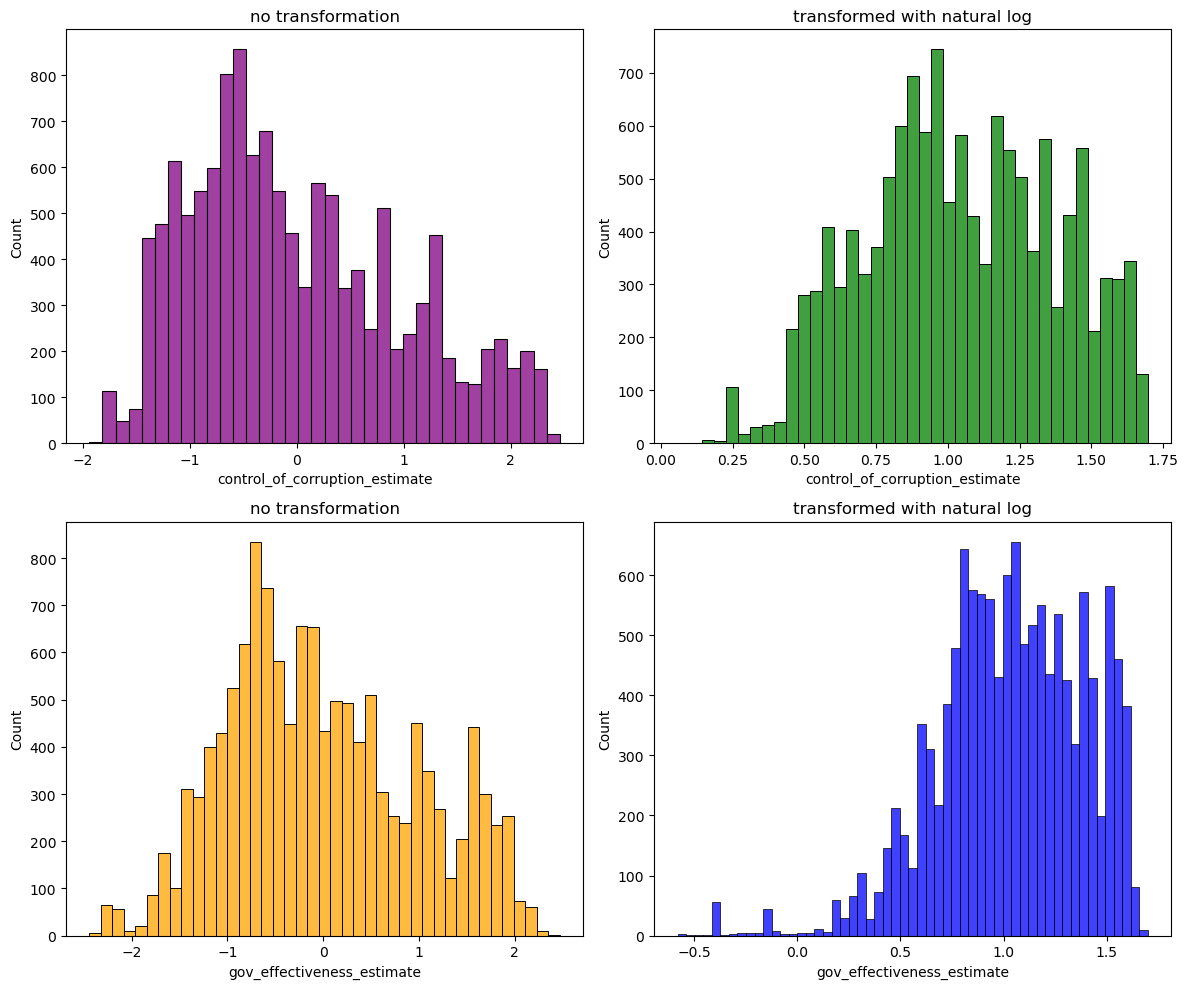

In [483]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ["purple", "green","orange", "blue"]

# Plot 1
sns.histplot(wb_df["control_of_corruption_estimate"], color=colors[0], ax=axes[0,0])
axes[0,0].set_title("no transformation")

# Plot 2 (natural log)
sns.histplot(corruption_log, color=colors[1], ax=axes[0,1])
axes[0,1].set_title("transformed with natural log")

# Plot 3
sns.histplot(wb_df["gov_effectiveness_estimate"], color=colors[2], ax=axes[1,0])
axes[1,0].set_title("no transformation")

# Plot 3 (natural log)
sns.histplot(gov_effectiveness_log, color=colors[3], ax=axes[1,1])
axes[1,1].set_title("transformed with natural log")

plt.tight_layout()
plt.show()

In [484]:
pg.normality(corruption_log)


c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12924.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
control_of_corruption_estimate,0.983884,1.151299e-35,False


In [485]:
pg.normality(gov_effectiveness_log)

c:\Users\sassa\miniconda3\envs\ASDA\lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 12924.
  res = hypotest_fun_out(*samples, **kwds)


,W,pval,normal
gov_effectiveness_estimate,0.968204,2.529666e-46,False


In [486]:
x = wb_df['control_of_corruption_estimate']
y = wb_df['gov_effectiveness_estimate']

Spearman correlation: rho = 0.918, p-value < 1e-10


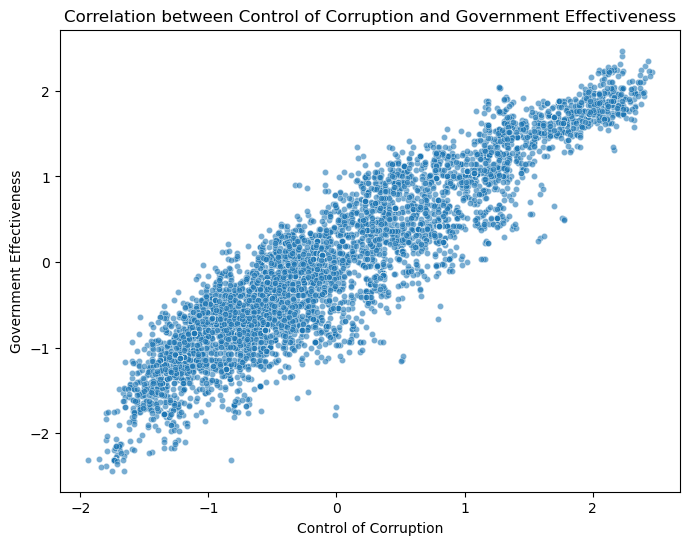

In [487]:
# Spearman correlation
r_spearman, p_spearman = spearmanr(x, y)
print(f'Spearman correlation: rho = {r_spearman:.3f}, p-value < 1e-10')

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=x, y=y, alpha=0.6, s=20)
plt.xlabel('Control of Corruption')
plt.ylabel('Government Effectiveness')
plt.title(f'Correlation between Control of Corruption and Government Effectiveness')
plt.show()

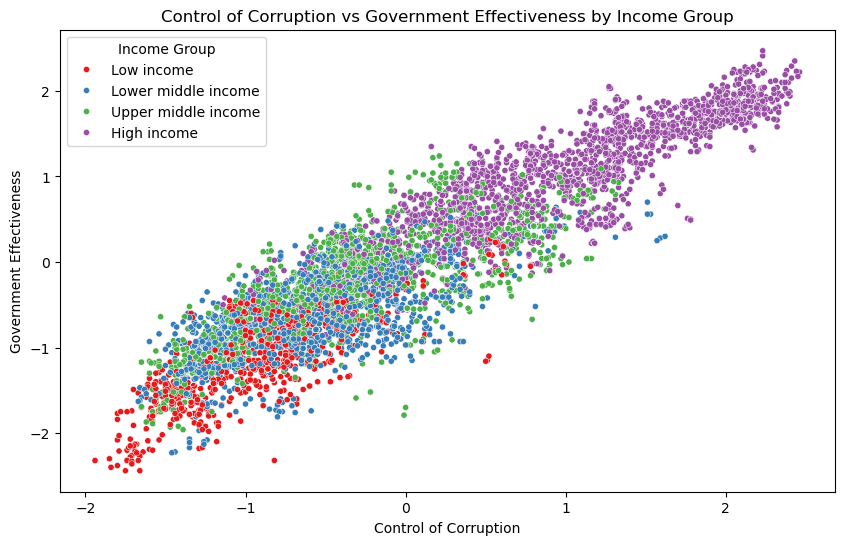

In [488]:
# Define the order
income_order = ['Low income', 'Lower middle income', 'Upper middle income', 'High income']

# Convert to categorical with order
wb_df['income_group'] = pd.Categorical(wb_df['income_group'], categories=income_order, ordered=True)

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=wb_df,
    x= x, 
    y= y, 
    hue='income_group', 
    palette='Set1', 
    s=20
)
plt.xlabel('Control of Corruption')
plt.ylabel('Government Effectiveness')
plt.title('Control of Corruption vs Government Effectiveness by Income Group')
plt.legend(title='Income Group')
plt.show()


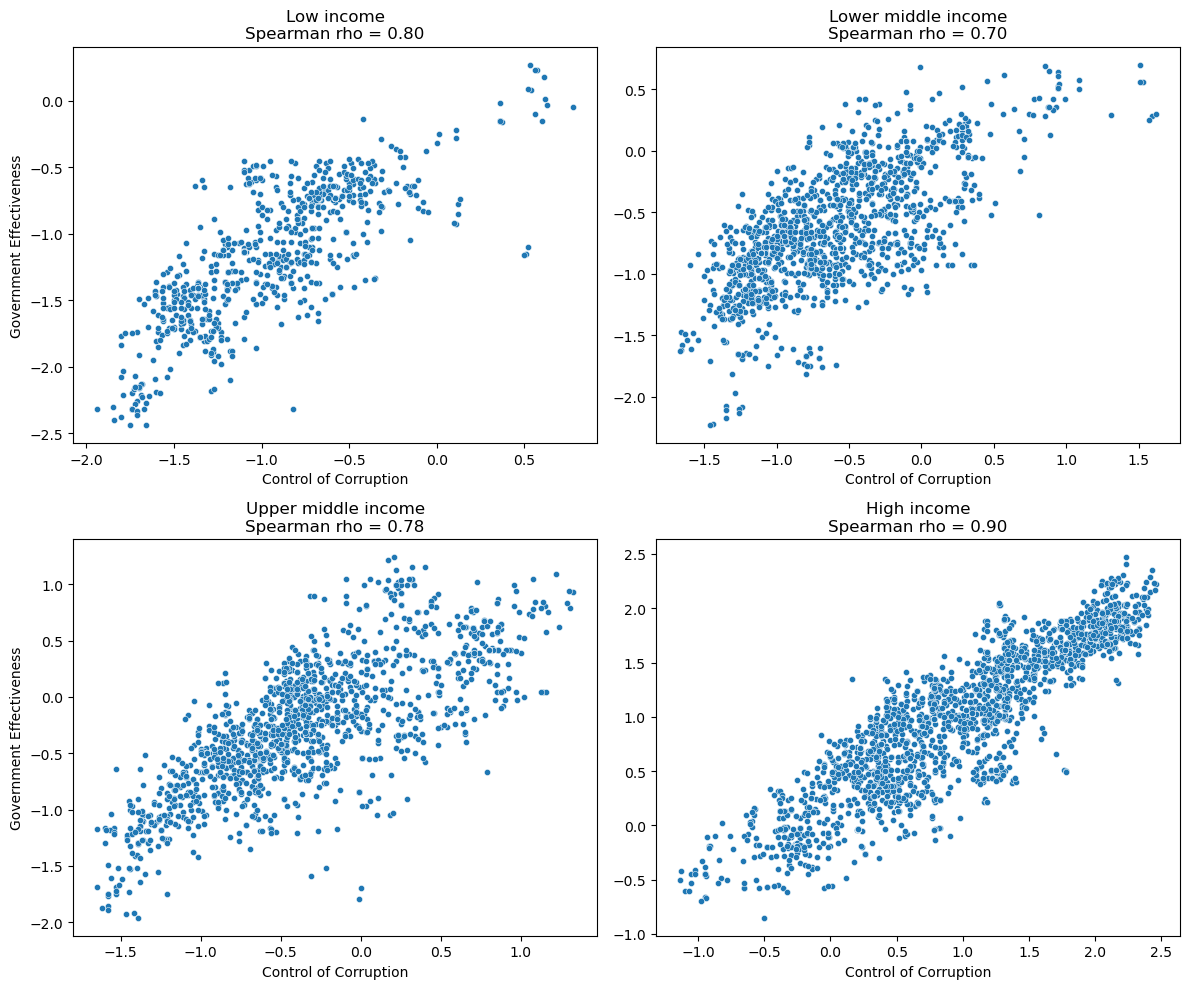

In [489]:
# Create 2x2 subplot
fig, axes = plt.subplots(2, 2, figsize=(12,10))

# 1. Low income
df = wb_df[wb_df['income_group'] == 'Low income']
sns.scatterplot(x=x[df.index], y=y[df.index], s=20, ax=axes[0,0])
rho, _ = spearmanr(x[df.index], y[df.index])
axes[0,0].set_title(f"Low income\nSpearman rho = {rho:.2f}")
axes[0,0].set_xlabel('Control of Corruption')
axes[0,0].set_ylabel('Government Effectiveness')

# 2. Lower middle income
df = wb_df[wb_df['income_group'] == 'Lower middle income']
sns.scatterplot(x=x[df.index], y=y[df.index], s=20, ax=axes[0,1])
rho, _ = spearmanr(x[df.index], y[df.index])
axes[0,1].set_title(f"Lower middle income\nSpearman rho = {rho:.2f}")
axes[0,1].set_xlabel('Control of Corruption')
axes[0,1].set_ylabel('')

# 3. Upper middle income
df = wb_df[wb_df['income_group'] == 'Upper middle income']
sns.scatterplot(x=x[df.index], y=y[df.index], s=20, ax=axes[1,0])
rho, _ = spearmanr(x[df.index], y[df.index])
axes[1,0].set_title(f"Upper middle income\nSpearman rho = {rho:.2f}")
axes[1,0].set_xlabel('Control of Corruption')
axes[1,0].set_ylabel('Government Effectiveness')

# 4. High income
df = wb_df[wb_df['income_group'] == 'High income']
sns.scatterplot(x=x[df.index], y=y[df.index], s=20, ax=axes[1,1])
rho, _ = spearmanr(x[df.index], y[df.index])
axes[1,1].set_title(f"High income\nSpearman rho = {rho:.2f}")
axes[1,1].set_xlabel('Control of Corruption')
axes[1,1].set_ylabel('')

plt.tight_layout()
plt.show()

In [506]:
# Step 1: create an empty list to store results
corr_list = []

# Step 2: loop through each country
for country in wb_df["country"].unique():
    # Filter data for the country and years 2000–2024
    df = wb_df[(wb_df["country"] == country) &
               (wb_df["year"] >= 2000) &
               (wb_df["year"] <= 2024)]
    
    # Only compute if we have at least 4 years of data
    if len(df) > 3:
        corr = df["control_of_corruption_estimate"].corr(df["gov_effectiveness_estimate"], method="spearman")
        region = df["region"].values[0]
        corr_list.append([country, region, corr])

# Step 3: convert list to DataFrame
corr_df = pd.DataFrame(corr_list, columns=["country", "region", "correlation"])

# Step 4: pick top 5 correlations (highest values)
top5 = corr_df.sort_values(by="correlation", ascending=False).head(5)

# Step 5: pick bottom 5 correlations (closest to 0)
# We'll use absolute value for "closeness to 0"
corr_df["abs_corr"] = corr_df["correlation"].abs()
bottom5 = corr_df.sort_values(by="abs_corr").head(5)

print("Top 5 correlated countries:")
print(top5[["country", "region", "correlation"]])

print("\nBottom 5 countries with correlation closest to 0:")
print(bottom5[["country", "region", "correlation"]])

Top 5 correlated countries:
           country                                             region  \
71       Greenland                              Europe & Central Asia   
201    Yemen, Rep.  Middle East, North Africa, Afghanistan & Pakistan   
58         Eritrea                                 Sub-Saharan Africa   
129          Nauru                                East Asia & Pacific   
45   Cote d'Ivoire                                 Sub-Saharan Africa   

     correlation  
71      0.953782  
201     0.947265  
58      0.942714  
129     0.941895  
45      0.938919  

Bottom 5 countries with correlation closest to 0:
           country                 region  correlation
106  Liechtenstein  Europe & Central Asia    -0.007417
195     Uzbekistan  Europe & Central Asia     0.009366
89           Italy  Europe & Central Asia     0.009387
176    Switzerland  Europe & Central Asia     0.010936
180       Thailand    East Asia & Pacific     0.026119


In [543]:
import pandas as pd

# List of countries
countries = ["Yemen, Rep.", "Thailand"]

# Filter the data
df_selected = wb_df[(wb_df["country"].isin(countries)) & 
                    (wb_df["year"] >= 2000) & (wb_df["year"] <= 2024)]

# Select relevant columns
df_table = df_selected[["country", "year", "control_of_corruption_estimate", "gov_effectiveness_estimate"]]

# Sort by country and year
df_table = df_table.sort_values(["country", "year"]).reset_index(drop=True)

# Display the table
print(df_table)


        country  year  control_of_corruption_estimate  \
0      Thailand  2000                           -0.23   
1      Thailand  2001                           -0.40   
2      Thailand  2002                           -0.34   
3      Thailand  2003                           -0.20   
4      Thailand  2004                           -0.25   
5      Thailand  2005                           -0.21   
6      Thailand  2006                           -0.41   
7      Thailand  2007                           -0.40   
8      Thailand  2008                           -0.44   
9      Thailand  2009                           -0.33   
10     Thailand  2010                           -0.36   
11     Thailand  2011                           -0.35   
12     Thailand  2012                           -0.40   
13     Thailand  2013                           -0.37   
14     Thailand  2014                           -0.48   
15     Thailand  2015                           -0.56   
16     Thailand  2016          

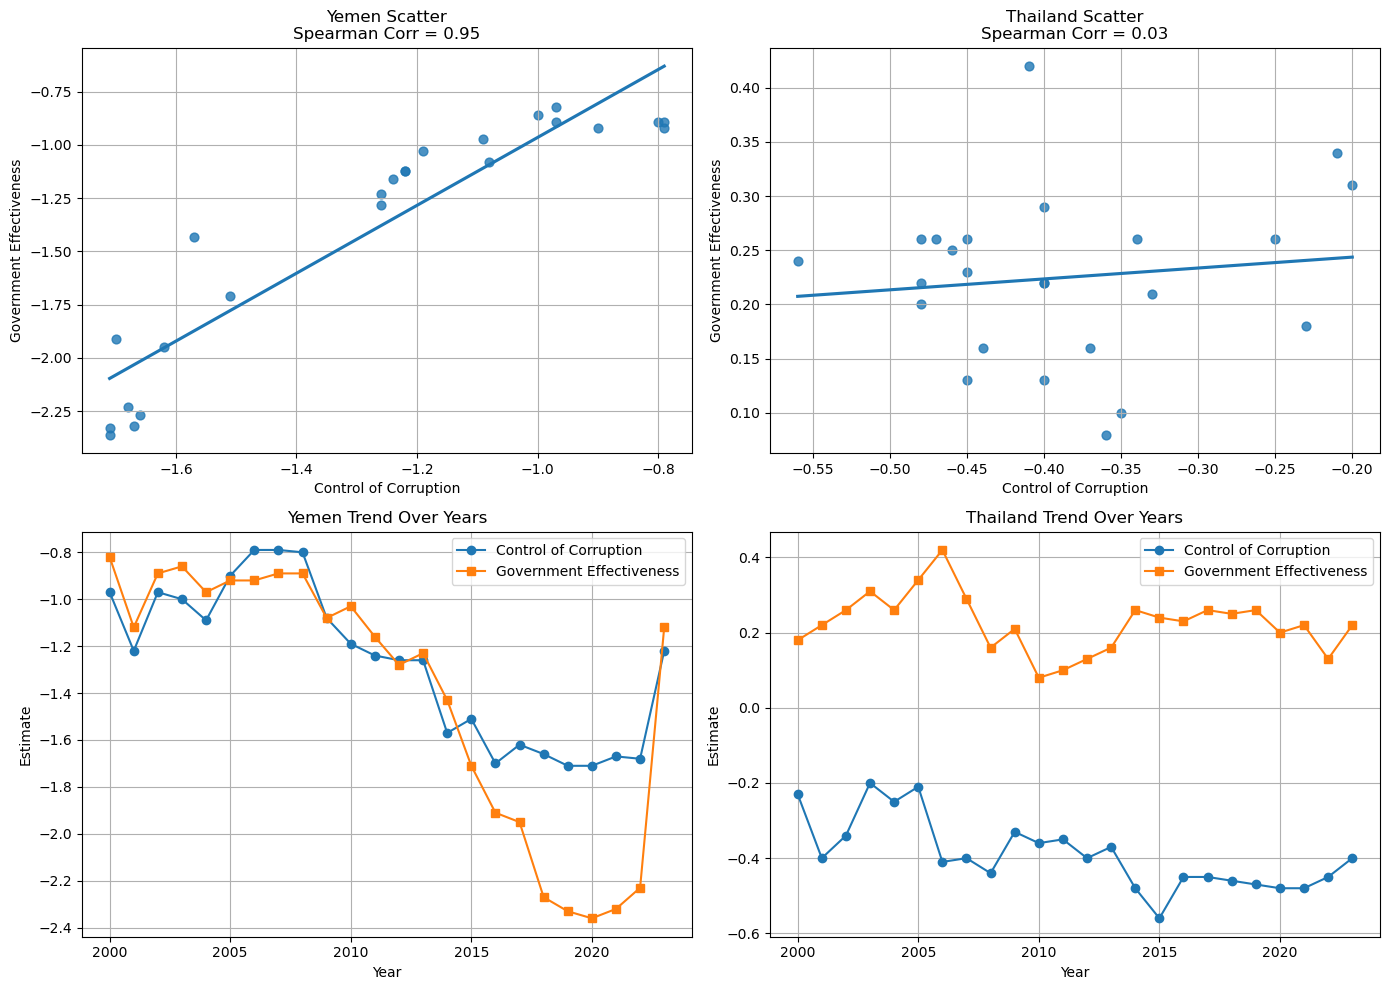

In [548]:
plt.figure(figsize=(14, 10))  # 2 rows × 2 columns

# --- Yemen ---
df_yemen = wb_df[(wb_df["country"] == "Yemen, Rep.") & 
                 (wb_df["year"] >= 2000) & (wb_df["year"] <= 2024)].sort_values("year")

# Scatter plot
plt.subplot(2, 2, 1)
sns.regplot(
    data=df_yemen,
    x="control_of_corruption_estimate",
    y="gov_effectiveness_estimate",
    scatter_kws={"s":40},
    ci=None
)
corr_yemen = df_yemen["control_of_corruption_estimate"].corr(df_yemen["gov_effectiveness_estimate"], method='spearman')
plt.title(f"Yemen Scatter\nSpearman Corr = {corr_yemen:.2f}")
plt.xlabel("Control of Corruption")
plt.ylabel("Government Effectiveness")
plt.grid(True)

# Line plot
plt.subplot(2, 2, 3)
plt.plot(df_yemen["year"], df_yemen["control_of_corruption_estimate"], marker='o', label="Control of Corruption")
plt.plot(df_yemen["year"], df_yemen["gov_effectiveness_estimate"], marker='s', label="Government Effectiveness")
plt.title("Yemen Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Estimate")
plt.legend()
plt.grid(True)

# --- Thailand ---
df_thailand = wb_df[(wb_df["country"] == "Thailand") & 
                       (wb_df["year"] >= 2000) & (wb_df["year"] <= 2024)].sort_values("year")

# Scatter plot
plt.subplot(2, 2, 2)
sns.regplot(
    data=df_thailand,
    x="control_of_corruption_estimate",
    y="gov_effectiveness_estimate",
    scatter_kws={"s":40},
    ci=None
)
corr_thailand = df_thailand["control_of_corruption_estimate"].corr(df_thailand["gov_effectiveness_estimate"], method='spearman')
plt.title(f"Thailand Scatter\nSpearman Corr = {corr_thailand:.2f}")
plt.xlabel("Control of Corruption")
plt.ylabel("Government Effectiveness")
plt.grid(True)

# Line plot
plt.subplot(2, 2, 4)
plt.plot(df_thailand["year"], df_thailand["control_of_corruption_estimate"], marker='o', label="Control of Corruption")
plt.plot(df_thailand["year"], df_thailand["gov_effectiveness_estimate"], marker='s', label="Government Effectiveness")
plt.title("Thailand Trend Over Years")
plt.xlabel("Year")
plt.ylabel("Estimate")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Analysis
1. Yemen is a country that has had political instability, civil war, and governance challenges over the past 20+ years. Because of this instability, both corruption and government effectiveness fluctuate together. For example:

- If the government introduces reforms → government effectiveness improves → corruption might also reduce.
- If there is a crisis or conflict → government effectiveness drops → corruption worsens.

This parallel movement means that when one indicator goes up or down, the other usually does too. That’s why the correlation is very high.

2. Thailand is a relatively stable country, but small changes in corruption and government effectiveness don’t always happen together.

- In some years, government effectiveness may improve slightly due to reforms, while corruption stays nearly the same.
- In other years, corruption may worsen a bit, but overall government effectiveness does not change much.

This lack of coordinated movement means that year-to-year fluctuations are not aligned, which is why the correlation between the two indicators is low.

In [552]:
# Pre-2008
df_pre2008 = wb_df[wb_df['year'] < 2008]

# Post-2008
df_post2008 = wb_df[wb_df['year'] >= 2008]

Pre-2008: Spearman rho = 0.92, p = 0.000e+00
Post-2008: Spearman rho = 0.91, p = 0.000e+00


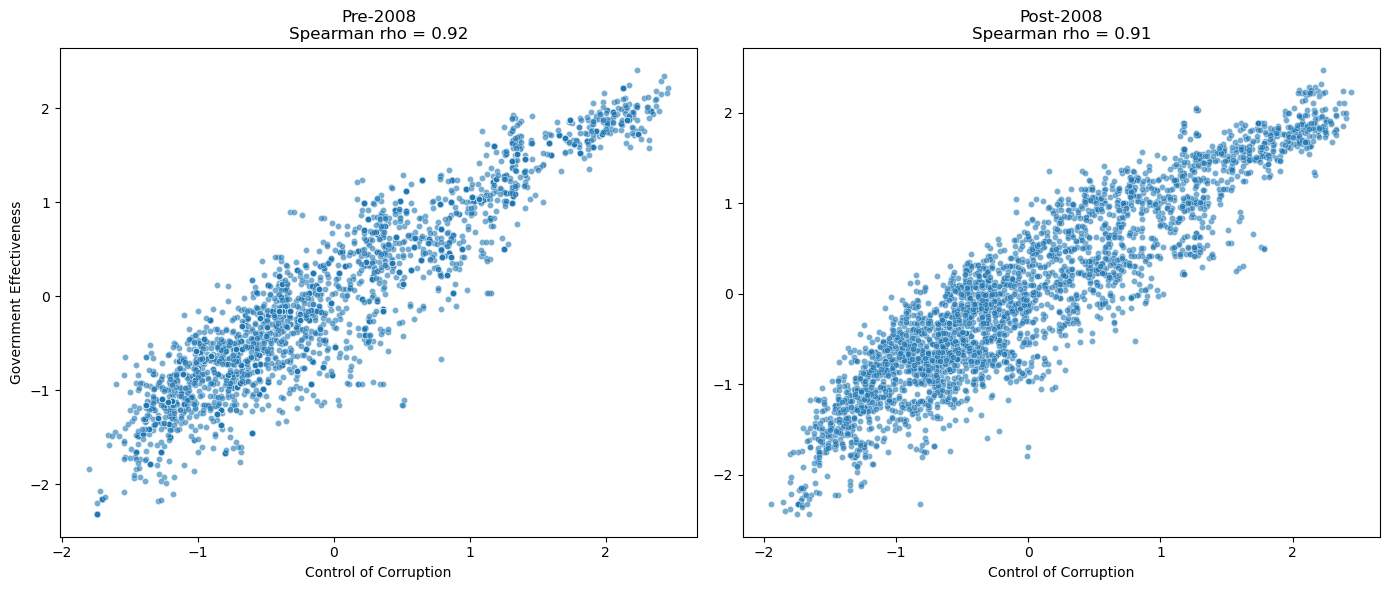

In [553]:
# Spearman correlations
rho_pre, p_pre = spearmanr(df_pre2008['control_of_corruption_estimate'],
                           df_pre2008['gov_effectiveness_estimate'])
rho_post, p_post = spearmanr(df_post2008['control_of_corruption_estimate'],
                             df_post2008['gov_effectiveness_estimate'])
print(f"Pre-2008: Spearman rho = {rho_pre:.2f}, p = {p_pre:.3e}")
print(f"Post-2008: Spearman rho = {rho_post:.2f}, p = {p_post:.3e}")
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(x=df_pre2008['control_of_corruption_estimate'],
                y=df_pre2008['gov_effectiveness_estimate'],
                s=20, alpha=0.6, ax=axes[0])
axes[0].set_title(f"Pre-2008\nSpearman rho = {rho_pre:.2f}")
axes[0].set_xlabel('Control of Corruption')
axes[0].set_ylabel('Government Effectiveness')

sns.scatterplot(x=df_post2008['control_of_corruption_estimate'],
                y=df_post2008['gov_effectiveness_estimate'],
                s=20, alpha=0.6, ax=axes[1])
axes[1].set_title(f"Post-2008\nSpearman rho = {rho_post:.2f}")
axes[1].set_xlabel('Control of Corruption')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()